In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
from datetime import datetime
from scipy.stats import poisson
from scipy.signal import fftconvolve
import time
from scipy.signal import find_peaks

# data_path = "/Volumes/RFsoc/ZCU208B/PNR_data"

data_path = '/Volumes/RFsoc/ZCU208B/Data/20260225/Matterhorn/gN2a15-12/Pulse_Laser_Source/Mean_Photon_Number=5/'

# data_path = '/Volumes/RFsoc/ZCU208B/Data/20260224/Matterhorn/gN2a7-2/Pulse_Laser_Source/Mean_Photon_Number=5/'




In [2]:
date = str(datetime.now())[0:10]
day = date[0:4]+date[5:7]+date[8:10]
s_live = str(datetime.now())
s_live[11:13] + s_live[14:16]





'1329'

In [3]:
device_name = "Matterhorn"
detector_name = "gN2a15-12-28pixel"
laser_name = "Pulse_Laser_Source"
mean_photon_number = 5
measurement_type = "Signal_analysis"



# plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "measurement.png"))

os.makedirs(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type), exist_ok=True)

#plt.savefig(os.path.join("Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "measurement.png"), dpi=500)

In [4]:
mu_5_data_1 = np.loadtxt(os.path.join(data_path, "1545/28pixel_Mu_5_5000.csv"), delimiter=",")
# mu_5_data_1 = np.loadtxt(os.path.join(data_path, "timestamp/Mu_5_5000.csv"), delimiter=",")
# mu_5_data_2 = np.loadtxt(os.path.join(data_path, "timestamp/Mu_5_1000.csv"), delimiter=",")

# Convert to (n_waveforms, n_samples)
mu_5_data_1 = mu_5_data_1.T
# mu_5_data_2 = mu_5_data_2.T

print(mu_5_data_1.shape)  # (5000, 16384) if that's what's in the file
#print(mu_5_data_2.shape)  # (1000, 16384)

(5000, 16384)


In [5]:
#mu_5_data = np.concatenate((mu_5_data_1, mu_5_data_2))
mu_5_data = mu_5_data_1
print(mu_5_data.shape)

(5000, 16384)


In [6]:
print(len(mu_5_data))

5000


In [34]:
def sinc_interp(x, s, u):
    if len(x) != len(s):
        raise ValueError('x and s must be the same length')
    
    # Find the period    
    T = s[1] - s[0]
    
    sincM = np.tile(u, (len(s), 1)) - np.tile(s[:, np.newaxis], (1, len(u)))
    y = np.dot(x, np.sinc(sincM/T))
    return y

def sinc_interpolate_fft(data, up=8):
    

    data = np.asarray(data, dtype=float)
    N = len(data)
    M = N * up

    # Forward FFT (real signal)
    W = np.fft.rfft(data)

    # Zero-pad spectrum
    W_pad = np.zeros(M // 2 + 1, dtype=W.dtype)
    W_pad[:len(W)] = W

    # Inverse FFT
    wave_up = np.fft.irfft(W_pad, n=M)

    # Scale to preserve amplitude
    wave_up *= up

    return wave_up


def pnr_counts(data, thresholds):
    
    pnr_counts = []
    number_of_thresholds = len(thresholds)
    
    for i in range(len(data)):
        for k in range(number_of_thresholds):
            if thresholds[k][0] <= data[i] < thresholds[k][1]:
                pnr_counts.append(k)
                
    return pnr_counts


def pnr_comparison_metrics(raw_counts, interp_counts):
    raw_counts = np.array(raw_counts)
    interp_counts = np.array(interp_counts)
    
    # Calculate mean
    mean_raw = np.mean(raw_counts)
    mean_interp = np.mean(interp_counts)
    
    # Calculate standard deviation
    std_raw = np.std(raw_counts)
    std_interp = np.std(interp_counts)
    
    # Calculate coefficient of variation
    cv_raw = std_raw / mean_raw
    cv_interp = std_interp / mean_interp
    
    return {
        "mean_raw": mean_raw,
        "mean_interp": mean_interp,
        "std_raw": std_raw,
        "std_interp": std_interp,
        "cv_raw": cv_raw,
        "cv_interp": cv_interp
    }
    

def max_using_chunks(data, chunk_size=500):
    max_values = []
    
    for k in range(len(data)):
        for i in range(0, len(data[k]), chunk_size):
            chunk = data[k][i:i+chunk_size]
            max_values.append(np.max(chunk))
                              
    return max_values

def extract_waveforms(data, chunk_size=500):
    waveforms = []
    
    for k in range(len(data)):
        for i in range(0, len(data[k]), chunk_size):
            chunk = data[k][i:i+chunk_size]
            waveforms.append(chunk)
                           
    return waveforms


def extract_pulse(data, points_before=5, points_after=5, chunk=500):
    pulses = []
    for k in range(len(data)):
        for i in range(0, len(data[k]), chunk):
            chunk_data = data[k][i:i+chunk]
            max_idx = np.argmax(chunk_data)
            start_idx = max(0, i + max_idx - points_before)
            end_idx = min(len(data[k]), i + max_idx + points_after + 1)
            pulses.append(data[k][start_idx:end_idx])
    return pulses

def extract_pulse_no_loop(data, points_before=5, points_after=5, chunk=500):
    pulses = []
    for i in range(0, len(data), chunk):
        chunk_data = data[i:i+chunk]
        max_idx = np.argmax(chunk_data)
        start_idx = max(0, i + max_idx - points_before)
        end_idx = min(len(data), i + max_idx + points_after + 1)
        pulses.append(data[start_idx:end_idx])
    return pulses
            
        

        


def areas_under_pulses(pulses):
    areas = []
    for pulse in pulses:
        area = np.trapz(pulse)
        areas.append(area)
    return areas
    
    
    
def upsample_windowed_sinc_fft(x, L=8, taps_per_phase=16, window="kaiser", beta=8.6):
    x = np.asarray(x, dtype=float)

    ntaps = int(L * taps_per_phase)
    if ntaps % 2 == 0:
        ntaps += 1
    n = np.arange(ntaps) - (ntaps - 1) / 2

    # Ideal interpolation lowpass for upsampling by L
    h = np.sinc(n / L)

    if window == "rect":
        w = np.ones(ntaps)
    elif window == "hann":
        w = np.hanning(ntaps)
    elif window == "hamming":
        w = np.hamming(ntaps)
    elif window == "kaiser":
        w = np.kaiser(ntaps, beta)
    else:
        raise ValueError("window must be 'kaiser', 'hann', 'hamming', or 'rect'")

    h *= w
    h = h / np.sum(h) * L  # DC normalize + compensate zero-stuffing

    # Zero-stuff
    x_up = np.zeros(len(x) * L, dtype=float)
    x_up[::L] = x

    # Linear convolution via FFT
    y_full = fftconvolve(x_up, h, mode="full")

    # Remove group delay to align so y[::L] ≈ x
    delay = (ntaps - 1) // 2
    y = y_full[delay : delay + len(x_up)]
    return y

def upsample_by_8_scopegrade(x, quality="default"):
    """
    quality: "fast" | "default" | "clean"
    """
    if quality == "fast":
        return upsample_windowed_sinc_fft(x, L=8, taps_per_phase=12, window="kaiser", beta=7.5)
    if quality == "default":
        return upsample_windowed_sinc_fft(x, L=8, taps_per_phase=16, window="kaiser", beta=8.6)
    if quality == "clean":
        return upsample_windowed_sinc_fft(x, L=8, taps_per_phase=32, window="kaiser", beta=11.0)
    raise ValueError("quality must be 'fast', 'default', or 'clean'")




def extract_photon_number_from_threshold(data, thresholds):
    photon_numbers = []
    for value in data:
        for k, (lower, upper) in enumerate(thresholds):
            if lower <= value < upper:
                photon_numbers.append(k)
                break
    return photon_numbers



import numpy as np



def cleaning_up_waveforms(data, threshold=34000):
    cleaned_waveforms = []
    for waveform in data:
        if np.any(waveform > threshold):
            cleaned_waveforms.append(waveform)
    return cleaned_waveforms



def crop_waveforms_around_threshold(data, threshold=34000, x_before=1, y_after=2):
    cropped_waveforms = []

    for waveform in data:
        indices = np.where(waveform > threshold)[0]

        if len(indices) == 0:
            continue  # skip waveforms that never pass threshold

        first_idx = indices[0]

        start = max(0, first_idx - x_before)
        end = min(len(waveform), first_idx + y_after + 1)

        cropped_waveform = waveform[start:end]
        cropped_waveforms.append(cropped_waveform)

    return cropped_waveforms

def normalize_waveforms_to_first_point(data):
    return [waveform - waveform[0] for waveform in data]




In [17]:
waveforms = extract_waveforms(mu_5_data)
print(len(waveforms))

165000


In [20]:
waveforms = cleaning_up_waveforms(waveforms, threshold=34000)
print(len(waveforms))

153697


In [ ]:
snspd_signal = crop_waveforms_around_threshold(waveforms, threshold=34000, x_before=3, y_after=6)

In [41]:
normalised_snspd_signal = normalize_waveforms_to_first_point(snspd_signal)
normalised_squared_snspd_signal = [np.square(p) for p in normalised_snspd_signal]

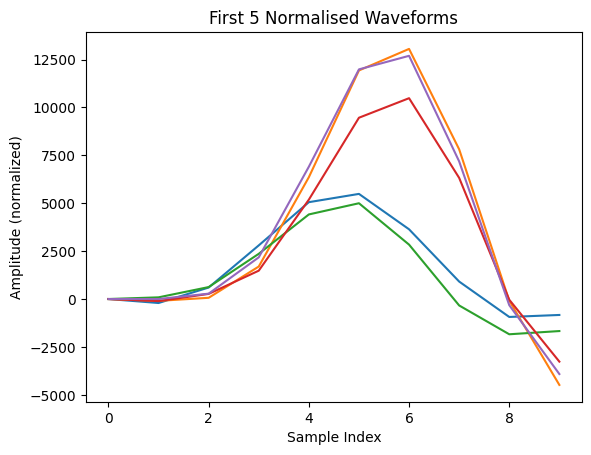

In [40]:
for i in range(5):
    plt.plot(normalised_snspd_signal[i])

plt.title("First 5 Normalised Waveforms")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (normalized)")
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "first_5_normalised_waveforms_2.png"), dpi=500)
plt.show()

/var/folders/0y/496_zl5905jfg059dd524bvm0000gn/T/ipykernel_35578/3994495998.py:124: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pulse)


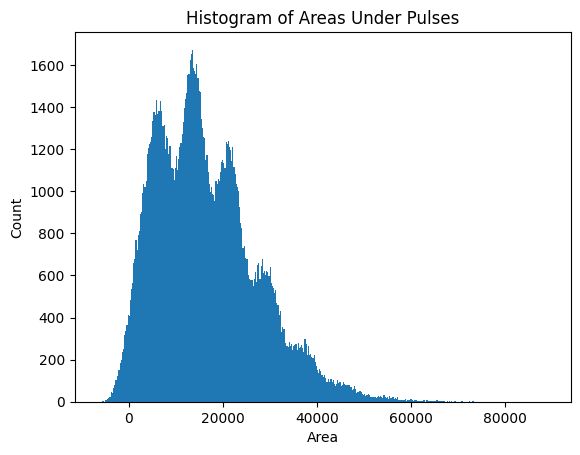

In [38]:
snspd_areas = areas_under_pulses(normalised_snspd_signal)
plt.hist(snspd_areas, bins=400)
plt.title("Histogram of Areas Under Pulses")
plt.xlabel("Area")
plt.ylabel("Count")
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "area_histogram_2ns_pulse.png"), dpi=500)
plt.show()


/var/folders/0y/496_zl5905jfg059dd524bvm0000gn/T/ipykernel_35578/3994495998.py:124: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pulse)


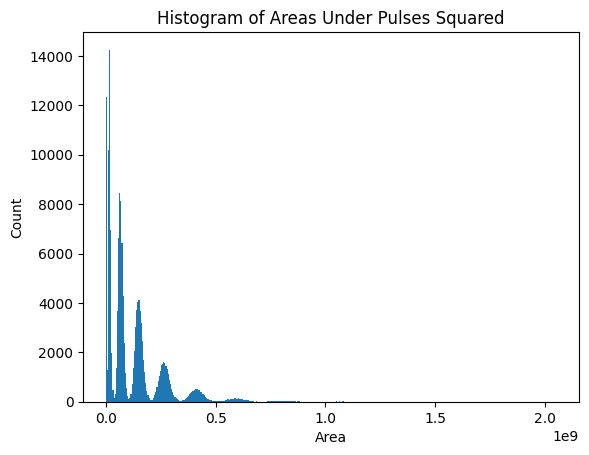

In [43]:
snspd_areas_squared = areas_under_pulses(normalised_squared_snspd_signal)
plt.hist(snspd_areas_squared, bins=400)
plt.title("Histogram of Areas Under Pulses Squared")
plt.xlabel("Area")
plt.ylabel("Count")
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "area_histogram_2ns_pulse_squared.png"), dpi=500)
plt.show()

In [9]:
interpolated_data = []

    
for i in range(len(mu_5_data)):
    interpolated_data.append(sinc_interpolate_fft(mu_5_data[i]))
    

print(len(interpolated_data))

5000


### Lets compare sinc interpolated vs non interpolated max amplitude

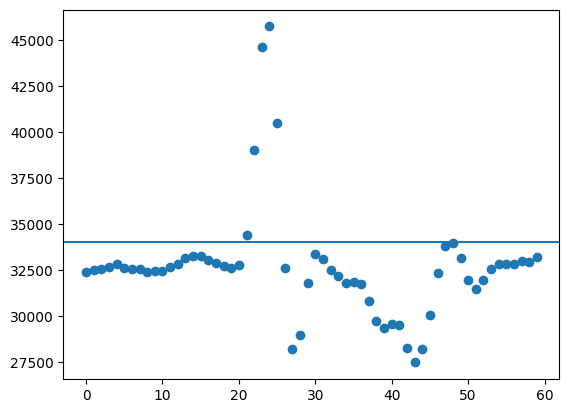

In [26]:
plt.plot(mu_5_data[0][540:600], "o")
plt.axhline(34000)

In [10]:
raw_max = max_using_chunks(mu_5_data)
print(len(raw_max))

165000


In [11]:
interpolated_max = max_using_chunks(interpolated_data, chunk_size=4000)
print(len(interpolated_max))

165000


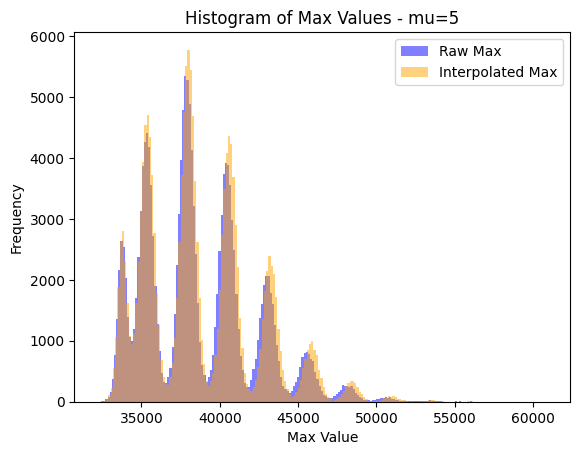

In [12]:
# os.makedirs(data_path + "/Signal_analysis", exist_ok=True)
# os.makedirs(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type), exist_ok=True)
# plt.figure(dpi=300)

counts_max, bin_max, _ =plt.hist(raw_max, bins=200, color='blue', alpha=0.5, label='Raw Max')
plt.hist(interpolated_max, bins=200, color='orange', alpha=0.5, label='Interpolated Max')
plt.legend()
plt.title('Histogram of Max Values - mu=5')
plt.xlabel('Max Value')
plt.ylabel('Frequency')


plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "8pixel_raw_vs_sinc_Interpolated_max_amplitude_histogram.png"), dpi=500)

plt.show()



In [13]:
pnr_comparison_metrics(raw_max, interpolated_max)



{'mean_raw': np.float64(38705.55076363636),
 'mean_interp': np.float64(38833.78158975006),
 'std_raw': np.float64(3550.654099156861),
 'std_interp': np.float64(3620.8647526705154),
 'cv_raw': np.float64(0.09173501033068052),
 'cv_interp': np.float64(0.09324007615128115)}

In [ ]:
raw_extracted_pulses = extract_pulse(mu_5_data, points_before=4, points_after=6, chunk=500)
raw_extracted_pulses_zeroed = [p - p[0] for p in raw_extracted_pulses if len(p) > 0]
raw_extracted_pulses_squared = [np.square(p) for p in raw_extracted_pulses_zeroed]

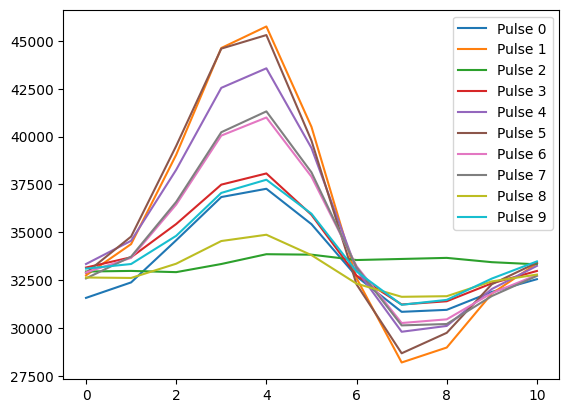

In [22]:
for i in range(10):
    plt.plot(raw_extracted_pulses[i], label=f"Pulse {i}")
plt.legend()
plt.show()    
    

In [16]:
raw_areas = areas_under_pulses(raw_extracted_pulses)
raw_areas_zeroed = areas_under_pulses(raw_extracted_pulses_zeroed)
raw_areas_squared_zeroed = areas_under_pulses(raw_extracted_pulses_squared)

/var/folders/0y/496_zl5905jfg059dd524bvm0000gn/T/ipykernel_3873/629349951.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pulse)


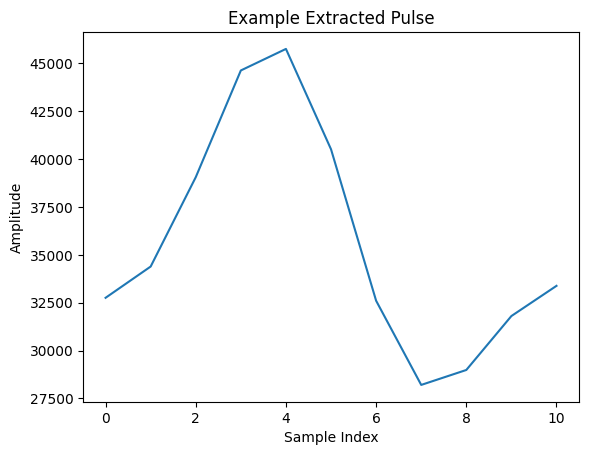

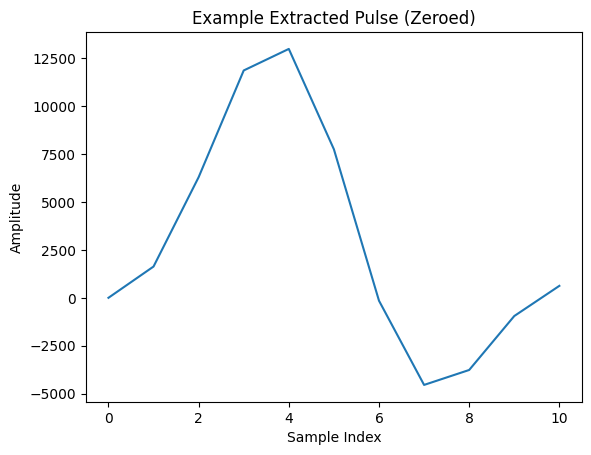

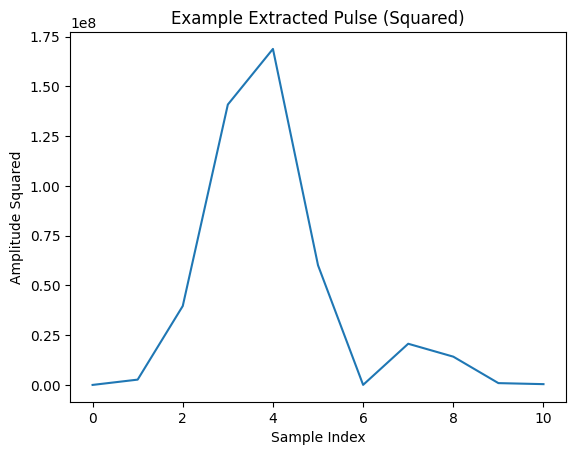

In [23]:
plt.plot(raw_extracted_pulses[1])
plt.title("Example Extracted Pulse")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "example_extracted_pulse.png"), dpi=500)
plt.show()

plt.plot(raw_extracted_pulses_zeroed[1])
plt.title("Example Extracted Pulse (Zeroed)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "example_extracted_pulse_zeroed.png"), dpi=500)
plt.show()

plt.plot(raw_extracted_pulses_squared[1])
plt.title("Example Extracted Pulse (Squared)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude Squared")
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "example_extracted_pulse_squared.png"), dpi=500)
plt.show()

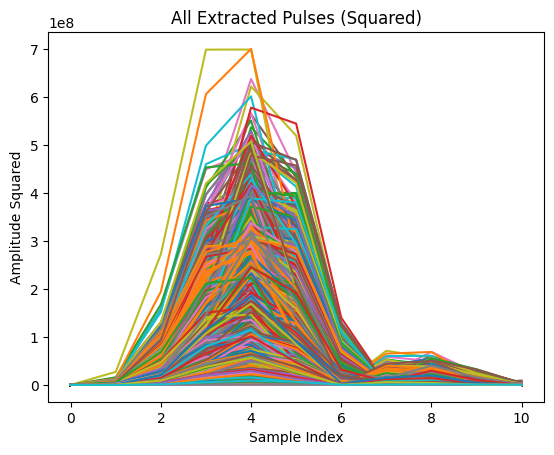

In [18]:

for i in range(len(raw_extracted_pulses_squared)):
    plt.plot(raw_extracted_pulses_squared[i])
plt.title("All Extracted Pulses (Squared)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude Squared")
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "all_extracted_pulses_squared.png"), dpi=500)
plt.show()

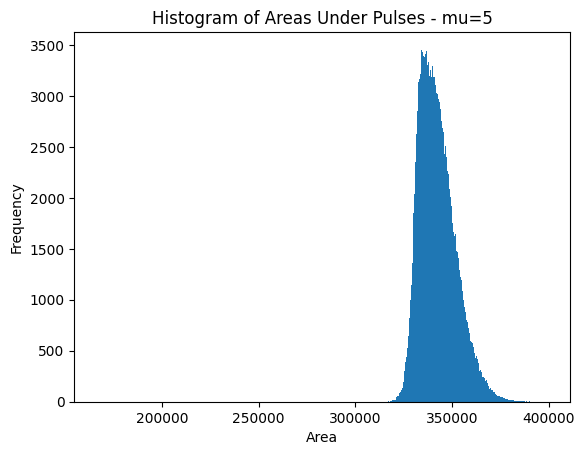

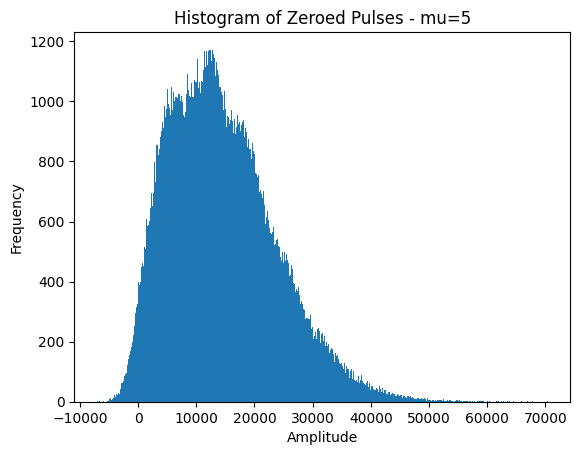

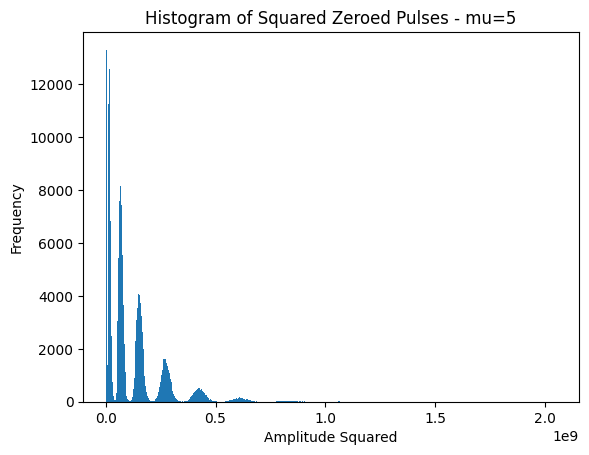

In [19]:
plt.hist(raw_areas, bins=500, label='Raw Area')
plt.title('Histogram of Areas Under Pulses - mu=5')
plt.xlabel('Area')
plt.ylabel('Frequency')
#plt.xlim(550000, 700000)
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "raw_area_histogram.png"), dpi=500)
plt.show()

plt.hist(raw_areas_zeroed, bins=500, label='Raw Area')
plt.title('Histogram of Zeroed Pulses - mu=5')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "zeroed_pulses_histogram.png"), dpi=500)
plt.show()

counts_squared, bins_squared, _ = plt.hist(raw_areas_squared_zeroed, bins=500, label='Raw Area')
plt.title('Histogram of Squared Zeroed Pulses - mu=5')
plt.xlabel('Amplitude Squared')
plt.ylabel('Frequency')
plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "squared_zeroed_pulses_histogram.png"), dpi=500)
plt.show()

In [24]:
thresholds, peaks, (counts, bins) = valley_thresholds_from_hist(
    samples=raw_areas_squared_zeroed,
    nbins=1000,
    smooth_sigma=1,
    peak_prominence=0.01,  # 5% of max peak height
    peak_distance=8
)

print("Peaks (x, height):")
for x, h in peaks:
    print(x, h)

print("\nValley thresholds between peaks:")
for t in thresholds:
    print(t["valley_x"], "count=", t["valley_count"])

Peaks (x, height):
17491906.584 6195.25750894027
66742601.88 3989.675705871546
152931318.648 2022.9854405501999
267849607.672 808.5930524434175
421758030.472 263.57335421064437
608500250.1359999 77.28481447738426

Valley thresholds between peaks:
40065141.928 count= 30.611730013233746
109836960.264 count= 11.17513970358017
208338350.856 count= 6.387819697649289
345829875.224 count= 3.0285331473530457
528467870.28 count= 0.6291403782713124


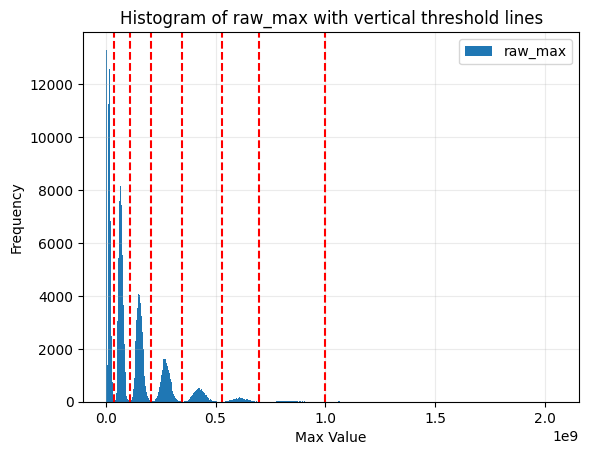

In [29]:
# Histogram of raw_max + vertical lines at chosen x values

# plt.figure(figsize=(10, 6), dpi=500)
counts_raw, bins_raw, _ = plt.hist(raw_areas_squared_zeroed, bins=500, label="raw_max")

# Option 1: manual x values (edit these)
x_lines = [40065141.928,109836960.264, 208338350.856 , 345829875.224, 528467870.28, 0.7e9, 1e9]

# Option 2 (automatic): valley thresholds found earlier
# x_lines = [t["valley_x"] for t in thresholds]

for xv in x_lines:
    plt.axvline(x=xv, color="red", linestyle="--", linewidth=1.5)

plt.title("Histogram of raw_max with vertical threshold lines")
plt.xlabel("Max Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

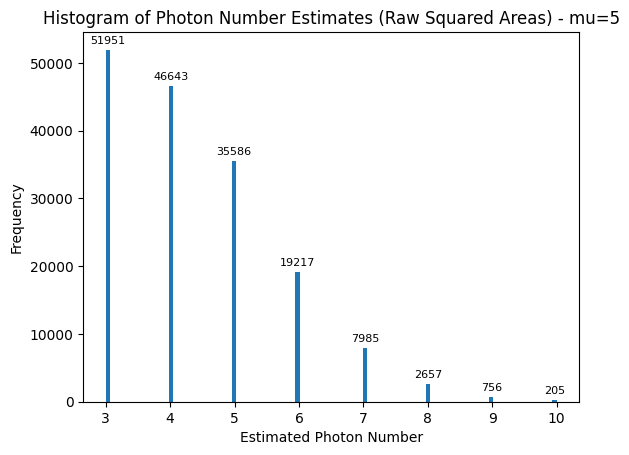

[51951.     0.     0.     0.     0.     0.     0.     0.     0.     0.
     0.     0.     0.     0. 46643.     0.     0.     0.     0.     0.
     0.     0.     0.     0.     0.     0.     0.     0. 35586.     0.
     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
     0.     0. 19217.     0.     0.     0.     0.     0.     0.     0.
     0.     0.     0.     0.     0.     0.     0.  7985.     0.     0.
     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
     0.  2657.     0.     0.     0.     0.     0.     0.     0.     0.
     0.     0.     0.     0.     0.   756.     0.     0.     0.     0.
     0.     0.     0.     0.     0.     0.     0.     0.     0.   205.]
[ 3.    3.07  3.14  3.21  3.28  3.35  3.42  3.49  3.56  3.63  3.7   3.77
  3.84  3.91  3.98  4.05  4.12  4.19  4.26  4.33  4.4   4.47  4.54  4.61
  4.68  4.75  4.82  4.89  4.96  5.03  5.1   5.17  5.24  5.31  5.38  5.45
  5.52  5.59  5.66  5.73  5.8   5.87  5.94  6.01  6.08  6.15  6.22  6.

In [ ]:
raw_photon_numbers = extract_photon_number_from_threshold(raw_areas_squared_zeroed, [(0,40065141.928), (40065141.928,109836960.264), (109836960.264, 208338350.856), (208338350.856, 345829875.224), (345829875.224, 528467870.28), (528467870.28, 0.7e9), (0.7e9, 1e9), (1e9, float('inf'))])
raw_photon_numbers = [n + 3 for n in raw_photon_numbers]
counts, bins, patches = plt.hist(raw_photon_numbers, bins=100)
plt.title('Histogram of Photon Number Estimates (Raw Squared Areas) - mu=5')
plt.xlabel('Estimated Photon Number')
plt.ylabel('Frequency')


for c, patch in zip(counts, patches):
    if c > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.annotate(
            f"{int(c)}",
            (x, y),
            xytext=(0, 3),          # offset in points
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )
        

plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_raw_photon_number_histogram_area_squared.png"), dpi=500)



plt.show()


print(counts)
print(bins)
print(len(bins))


In [ ]:
thresholds, peaks, (counts, bins) = valley_thresholds_from_hist(
    samples=raw_max,
    nbins=500,
    smooth_sigma=1,
    peak_prominence=0.01,  # 5% of max peak height
    peak_distance=8
)

print("Peaks (x, height):")
for x, h in peaks:
    print(x, h)

print("\nValley thresholds between peaks:")
for t in thresholds:
    print(t["valley_x"], "count=", t["valley_count"])

In [ ]:
# Histogram of raw_max + vertical lines at chosen x values

# plt.figure(figsize=(10, 6), dpi=300)
counts_raw, bins_raw, _ = plt.hist(raw_max, bins=500, label="raw_max")

# Option 1: manual x values (edit these)
x_lines = [34312, 36596, 39207, 41764, 44483, 47148.996, 49596.636, 52200]

# Option 2 (automatic): valley thresholds found earlier
# x_lines = [t["valley_x"] for t in thresholds]

for xv in x_lines:
    plt.axvline(x=xv, color="red", linestyle="--", linewidth=1.5)

plt.title("Histogram of raw_max with vertical threshold lines")
plt.xlabel("Max Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
raw_photon_numbers = extract_photon_number_from_threshold(raw_max, [(0, 34312), (34312, 36596), (36596, 39207), (39207, 41764), (41764, 44483), (44483, 47148.996), (47148.996, 49596.636), (49596.636, 52200), (52200, np.inf)])
raw_photon_numbers = [n + 3 for n in raw_photon_numbers]
counts, bins, patches = plt.hist(raw_photon_numbers, bins=100)
plt.title('Histogram of Photon Number Estimates (Raw Max) - mu=5')
plt.xlabel('Estimated Photon Number')
plt.ylabel('Frequency')


for c, patch in zip(counts, patches):
    if c > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.annotate(
            f"{int(c)}",
            (x, y),
            xytext=(0, 3),          # offset in points
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )
        

plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_raw_photon_number_histogram.png"), dpi=500)



plt.show()


print(counts)
print(bins)
print(len(bins))


In [ ]:
raw_photon_counts_squared = extract_photon_number_from_threshold(raw_areas_squared_zeroed, [(0, 1.03e7), (1.03e7, 7.5e7), (7.5e7, 0.25e9), (0.25e9, 0.5e9), (0.5e9, 0.8e9), (0.8e9, 1.15e9), (1.15e9, 3.0e9)])
raw_photon_counts_squared = [n + 3 for n in raw_photon_counts_squared]
counts_photon_squared, bins_photon_squared, patches_photon_squared = plt.hist(raw_photon_counts_squared, bins=100, label='Raw Area')
plt.title('Histogram of Photon Number Estimates (Squared Area) - mu=5')
plt.xlabel('Estimated Photon Number')
plt.ylabel('Frequency')



for c, patch in zip(counts_photon_squared, patches_photon_squared):
    if c > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.annotate(
            f"{int(c)}",
            (x, y),
            xytext=(0, 3),          # offset in points
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.savefig(os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "8pixel_squared_area_photon_number_histogram.png"), dpi=500)
plt.show()
print(counts_photon_squared)
print(bins_photon_squared)

In [ ]:
plt.figure(figsize=(10, 6), dpi=500)
for i in range(len(raw_extracted_pulses_squared)):
    plt.plot(raw_extracted_pulses_squared[i])
plt.show()

In [ ]:
counts2, bins2, _ = plt.hist(raw_areas_squared_zeroed, bins=7, label='Raw Area')

plt.show()

print(counts2)
print(bins2)
print(len(raw_areas_squared_zeroed))

In [ ]:
interpolated_extracted_pulses = extract_pulse(interpolated_data, points_before=32, points_after=32, chunk=4000)

In [ ]:
plt.plot(interpolated_extracted_pulses[0])

In [ ]:
raw_extracted_pulses_zeroed = [p - p[0] for p in raw_extracted_pulses if len(p) > 0]
interpolated_extracted_pulses_zeroed = [p - p[0] for p in interpolated_extracted_pulses if len(p) > 0]

In [ ]:
#plt.figure(dpi=300)
for i in range(len(raw_extracted_pulses)):
    plt.plot(raw_extracted_pulses[i])
    
plt.title('Extracted Pulses from Raw Data - mu=5')
plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_raw_extracted_pulses.png"), dpi=500)
plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_raw_extracted_pulses.pdf"), dpi=500)
    
plt.show()

In [ ]:
#plt.figure(dpi=300)
for i in range(len(interpolated_extracted_pulses)):
    plt.plot(interpolated_extracted_pulses[i])

plt.title('Extracted Pulses from Interpolated Data - mu=5')
plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_interpolated_extracted_pulses.png"), dpi=500)
plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_interpolated_extracted_pulses.pdf"), dpi=500)
plt.show()

In [ ]:
print(len(raw_extracted_pulses_zeroed))

In [ ]:
raw_areas = areas_under_pulses(raw_extracted_pulses)
# raw_areas_zeroed = areas_under_pulses(raw_extracted_pulses_zeroed)
# interpolated_area = 


In [ ]:
# plt.figure(dpi=300)
plt.hist(raw_areas, bins=100)
plt.title('Histogram of Areas Under Extracted Pulses - mu=5')
plt.xlabel('Area')
plt.ylabel('Frequency')
# plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_raw_extracted_pulse_areas_histogram.png"), dpi=500)
# plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_raw_extracted_pulse_areas_histogram.pdf"), dpi=500)
plt.show()


print(len(raw_areas))
print(np.min(raw_areas), np.max(raw_areas))

In [ ]:
interpolated_extracted__areas = areas_under_pulses(interpolated_extracted_pulses)
plt.hist(interpolated_extracted__areas, bins=100)
plt.title('Histogram of Interpolated Extracted Pulse Areas - mu=5')
plt.xlabel('Area')
plt.ylabel('Frequency')
# plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_interpolated_extracted_pulses_histogram.png"), dpi=500)
# plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "28pixel_interpolated_extracted_pulses_histogram.pdf"), dpi=500)
plt.show()  

In [ ]:
# plt.figure(dpi=300)
plt.hist(raw_areas_zeroed, bins=100)
plt.title('Histogram of Areas Under Extracted Pulses - mu=5')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "raw_extracted_pulse_areas_histogram.png"), dpi=500)
plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "raw_extracted_pulse_areas_histogram.pdf"), dpi=500)
plt.show()


print(len(raw_areas_zeroed))
print(np.min(raw_areas_zeroed), np.max(raw_areas_zeroed))

In [ ]:
plt.plot(mu_5_data[0])
print(np.max(mu_5_data[0]))

In [ ]:
y = upsample_by_8_scopegrade(mu_5_data[0], quality="clean")
# y has length 16384*8 = 131072

In [ ]:
plt.plot(y)

print(np.max(y) )
plt.show()

In [ ]:
w = upsample_windowed_sinc_fft(mu_5_data[0], taps_per_phase=24, window="kaiser", beta=11)

In [ ]:
plt.plot(w)
plt.show() 
print(np.max(w) )